# How Many Times Can You Differentiate a Convex Function?

## Is a convex function **Continuous**?

Yes.

Not only that, but also a convex function is **locally Lipschitz continuous**.

References:

* “Every Convex Function Is Locally Lipschitz.” The American Mathematical Monthly 79, no. 10 (1972): 1121–24. [DOI](https://doi.org/10.2307/2317434).
* Roberts, A. W., and D. E. Varberg. “Another Proof That Convex Functions Are Locally Lipschitz.” The American Mathematical Monthly 81, no. 9 (1974): 1014–16. [DOI](https://doi.org/10.2307/2319313).
* Alto's Vault (Hongda). “Convex Function Is Locally Lipschitz.” AMATH 516 Numerical Optimizations - Non-Smooth Calculus. [URL](https://publish.obsidian.md/alto/AMATH+516+Numerical+Optimizations/Non-Smooth+Calculus/Convex+Function+is+Locally+Lipschitz).

# Is a convex function **Differentiable**? 

Not always. Counterexample: $f(x) = |x|$ is a convex function which is non-differentiable at $x=0$.

But yes, almost everywhere. It follows from [Rademacher's Theorem (wikipedia)](https://en.wikipedia.org/wiki/Rademacher%27s_theorem).

In fact, a convex function is **TWICE differentiable almost everywhere**! The [Alexandrov Theorem (wikipedia)](https://en.wikipedia.org/wiki/Alexandrov_theorem) states it.

## Okay, then, how about **third-order** derivatives?

**NO,** a convex function need not be 3-times differentiable almost everywhere.

In fact, a convex function can be 3-times differentiable **NOWHERE.**

Conterexample: a double integral of a linearly-transformed [Weierstrass function (wikipedia)](https://en.wikipedia.org/wiki/Weierstrass_function).

* Weierstrass function is:
  * continuous everywhere;
  * differentiable nowhere;
  * bounded.

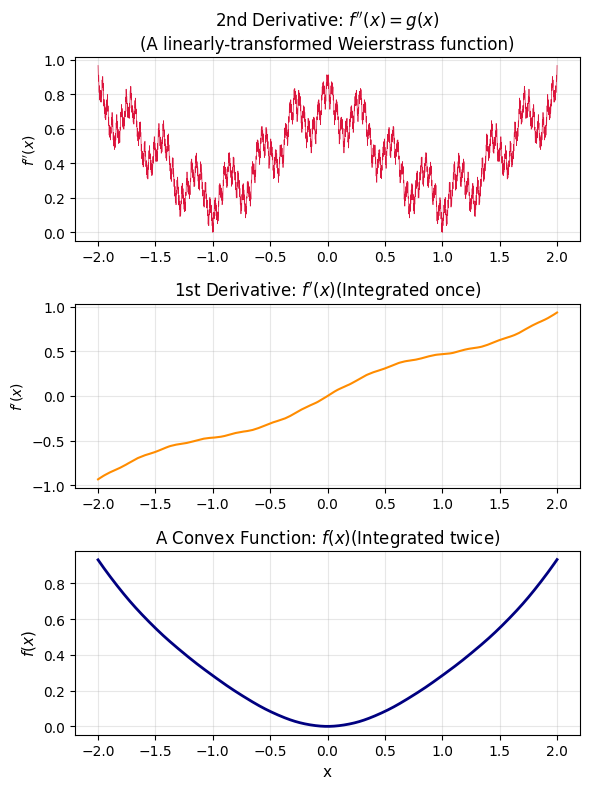

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid

# 1. Define the Weierstrass function
def weierstrass(x, a=0.5, b=7, iters=50):
    w = np.zeros_like(x)
    for n in range(iters):
        w += (a**n) * np.cos((b**n) * np.pi * x)
    return w

x = np.linspace(-2, 2, 5000)
W = weierstrass(x) * 0.25 # Scale down to [-0.5, 0.5]

# 2. Shift to make non-negative (g(x) = f''(x))
g = W - np.min(W)

# 3. Integrate once to get f'(x)
f_prime = cumulative_trapezoid(g, x, initial=0)
# Adjust so that f'(0) = 0
idx_zero = np.argmin(np.abs(x))
f_prime = f_prime - f_prime[idx_zero]

# 4. Integrate twice to get f(x)
f = cumulative_trapezoid(f_prime, x, initial=0)
# Adjust so that f(0) = 0
f = f - f[idx_zero]

# 5. Plotting
fig, axs = plt.subplots(3, 1, figsize=(6, 8))

# Second derivative
axs[0].plot(x, g, color='crimson', linewidth=0.5)
axs[0].set_title("2nd Derivative: $f''(x) = g(x)$\n(A linearly-transformed Weierstrass function)")
axs[0].set_ylabel("$f''(x)$")
axs[0].grid(True, alpha=0.3)

# First derivative
axs[1].plot(x, f_prime, color='darkorange', linewidth=1.5)
axs[1].set_title("1st Derivative: $f'(x)$(Integrated once)")
axs[1].set_ylabel("$f'(x)$")
axs[1].grid(True, alpha=0.3)

# The function
axs[2].plot(x, f, color='navy', linewidth=2)
axs[2].set_title("A Convex Function: $f(x)$(Integrated twice)", fontsize=12)
axs[2].set_xlabel("x", fontsize=11)
axs[2].set_ylabel("$f(x)$", fontsize=11)
axs[2].grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig("pathological_convex_1.png")

## Is a convex function $C^2$ almost everywhere?

The counterexample above was indeed $C^2$, as the Weierstrass function is continuous.

However... a convex function is not necessarily $C^2$ almost everywhere (though twice differentiable a.e.).

Actually, a convex function can be $C^2$ **NOWHERE**.

Counterexample:

* Let $\{q_1, q_2, q_3, \dots\}$ be an enumeration of all the rational numbers in the interval $[0, 1]$. Consider a function: $$f(x) = \sum_{n=1}^{\infty} \frac{1}{2^n} |x - q_n|.$$
    * It is **convex**, as it is a positively-weighted average of convex functions ($|x-q_n|$).
    * It is **twice differentiable**, as its pointwise second derivative $f''(x)$ is exactly $0$ almost everywhere. Thus, it doesn't contradict Alexandrov theorem.
    * It is **nowhere $C^2$**, as $f'(x)$ jumps constantly, which is discontinuous on any open interval (and so does $f''(x)$).

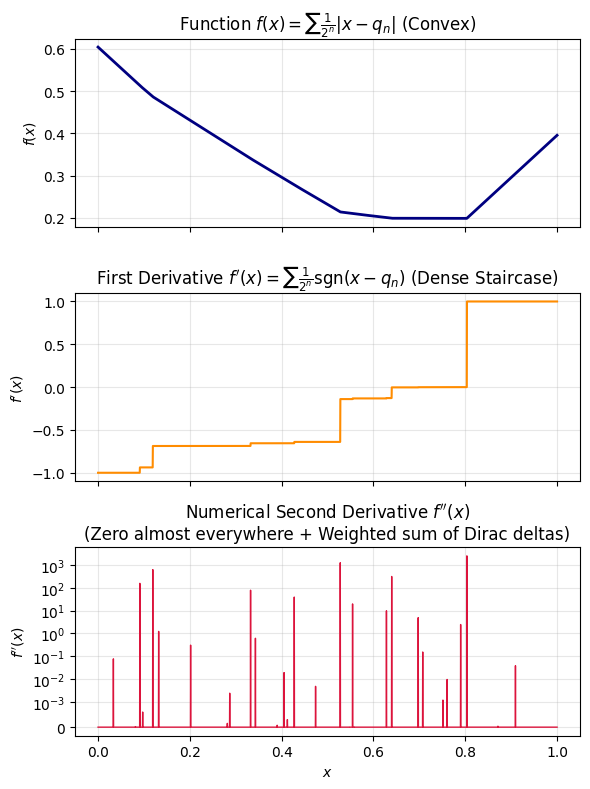

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def generate_counterexample_plot(num_terms, num_points):
    """
    Generates a plot of a nowhere C^2 convex function, 
    along with its first and numerical second derivatives.
    """
    # 1. Setup the domain
    x = np.linspace(0, 1, num_points)
    
    # 2. Generate a "dense" sequence of points in [0, 1]
    # We use a fixed random seed for reproducibility
    np.random.seed(999)
    q = np.random.rand(num_terms) 
    
    # 3. Generate the weights (1/2^n)
    n = np.arange(1, num_terms + 1)
    w = 1.0 / (2.0 ** n)
    
    # 4. Initialize arrays for f(x) and f'(x)
    y = np.zeros_like(x)
    dy = np.zeros_like(x)
    
    # 5. Build the function and its first derivative
    for qi, wi in zip(q, w):
        y += wi * np.abs(x - qi)
        
        # The derivative of |x - q| is sign(x - q)
        # Note: exactly at x=qi, the derivative is strictly undefined, 
        # but np.sign handles it by outputting 0, which falls within the subdifferential.
        dy += wi * np.sign(x - qi)
        
    # 6. Calculate the numerical second derivative
    # Analytically, this is a sum of Dirac deltas. Numerically, we will see 
    # zero almost everywhere with large spikes where the jumps occur.
    ddy = np.gradient(dy, x)
    
    # 7. Plotting
    fig, axs = plt.subplots(3, 1, figsize=(6, 8), sharex=True)
    
    # Plot f(x)
    axs[0].plot(x, y, color='navy', linewidth=2)
    axs[0].set_title(r"Function $f(x) = \sum \frac{1}{2^n} |x - q_n|$ (Convex)")
    axs[0].set_ylabel(r"$f(x)$")
    axs[0].grid(True, alpha=0.3)
    
    # Plot f'(x)
    axs[1].plot(x, dy, color='darkorange', linewidth=1.5)
    axs[1].set_title(r"First Derivative $f'(x) = \sum \frac{1}{2^n} \text{sgn}(x - q_n)$ (Dense Staircase)")
    axs[1].set_ylabel(r"$f'(x)$")
    axs[1].grid(True, alpha=0.3)
    
    # Plot f''(x)
    # We use a scatter plot or vlines to better represent the "spikes" of the numerical delta functions
    axs[2].plot(x, ddy, color='crimson', linewidth=1)
    axs[2].set_title(r"Numerical Second Derivative $f''(x)$"+"\n(Zero almost everywhere + Weighted sum of Dirac deltas)")
    axs[2].set_ylabel(r"$f''(x)$")
    axs[2].set_xlabel(r"$x$")
    axs[2].grid(True, alpha=0.3)
    axs[2].set_yscale('symlog', linthresh=1e-3)  
    
    fig.tight_layout()
    fig.savefig("pathological_convex_2.png")

# Run the visualization
generate_counterexample_plot(num_terms=500, num_points=5000)